##Data Collection

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from datetime import datetime


In [53]:
now = datetime.now()
ticker = 'AAPL'
start = datetime(now.year-10,now.month,now.day)
end = now

df = yf.download(ticker,start,end)
df


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2016-06-27,20.952875,21.182802,20.829944,21.171419,181958400
2016-06-28,21.305725,21.321662,20.975634,21.148648,161779600
2016-06-29,21.490128,21.524275,21.314836,21.392238,146124000
2016-06-30,21.763309,21.802010,21.467366,21.499237,143345600
2016-07-01,21.829327,21.961364,21.701843,21.738266,104106000
...,...,...,...,...,...
2026-06-18,298.010010,300.570007,295.619995,298.109985,85962200
2026-06-22,297.010010,302.420013,296.760010,297.309998,44879900


In [54]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2016-06-27,20.952875,21.182802,20.829944,21.171419,181958400
2016-06-28,21.305725,21.321662,20.975634,21.148648,161779600
2016-06-29,21.490128,21.524275,21.314836,21.392238,146124000
2016-06-30,21.763309,21.802010,21.467366,21.499237,143345600
2016-07-01,21.829327,21.961364,21.701843,21.738266,104106000


In [55]:
df.tail()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2026-06-18,298.010010,300.570007,295.619995,298.109985,85962200
2026-06-22,297.010010,302.420013,296.760010,297.309998,44879900
2026-06-23,294.299988,301.640015,294.179993,297.540009,52010900
2026-06-24,293.079987,299.700012,292.940002,295.359985,53081900
2026-06-25,275.149994,288.799988,273.750000,287.399994,107013700


#Data exploration & Visualization

In [56]:
type(df)

pandas.DataFrame

In [57]:
df.shape

(2513, 5)

In [58]:
df.isnull().sum()

Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64

In [59]:
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,2513.000000,2513.000000,2513.000000,2513.000000,2.513000e+03
mean,126.061073,127.330848,124.691387,125.957656,9.582174e+07
std,77.688780,78.469392,76.887264,77.647116,5.459571e+07
min,20.952875,21.182802,20.829944,21.148648,1.791060e+07
25%,45.473835,45.756564,44.979040,45.426884,5.669700e+07
50%,130.774811,132.019338,129.573750,131.055377,8.411800e+07
75%,182.187775,183.687528,180.301499,181.860468,1.159568e+08
max,315.200012,317.399994,309.649994,314.179993,4.479400e+08


In [60]:
df.Close

Ticker,AAPL
Date,
2016-06-27,20.952875
2016-06-28,21.305725
2016-06-29,21.490128
2016-06-30,21.763309
2016-07-01,21.829327
...,...
2026-06-18,298.010010
2026-06-22,297.010010
2026-06-23,294.299988


In [61]:
df = df.reset_index()

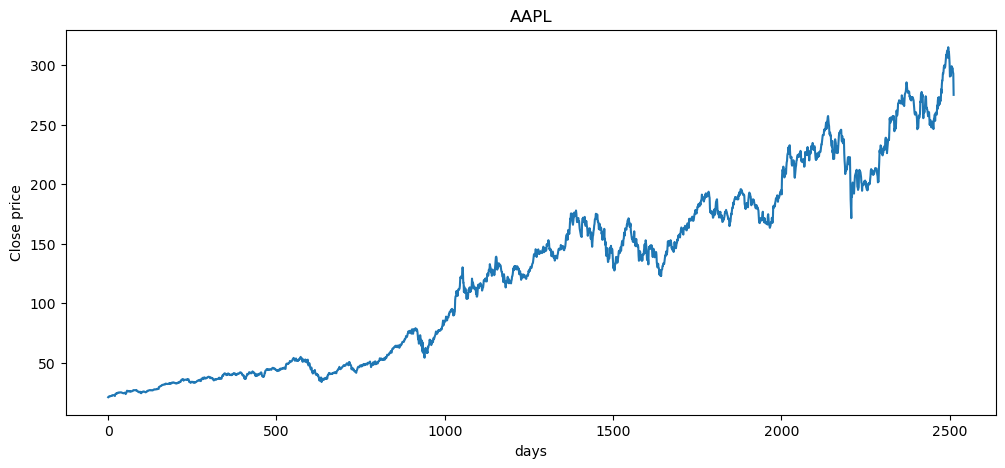

In [62]:
plt.figure(figsize=(12,5))
plt.plot(df.Close);
plt.title(ticker);
plt.xlabel('days')
plt.ylabel('Close price');

In [63]:
#100 days MA

df['MA_100'] = df.Close.rolling(100).mean()
df['MA_100'].head(103)

0            NaN
1            NaN
2            NaN
3            NaN
4            NaN
         ...    
98           NaN
99     24.661518
100    24.705030
101    24.744922
102    24.783222
Name: MA_100, Length: 103, dtype: float64

In [64]:
df

Price,Date,Close,High,Low,Open,Volume,MA_100
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL,
0,2016-06-27,20.952875,21.182802,20.829944,21.171419,181958400,NaN
1,2016-06-28,21.305725,21.321662,20.975634,21.148648,161779600,NaN
2,2016-06-29,21.490128,21.524275,21.314836,21.392238,146124000,NaN
3,2016-06-30,21.763309,21.802010,21.467366,21.499237,143345600,NaN
4,2016-07-01,21.829327,21.961364,21.701843,21.738266,104106000,NaN
...,...,...,...,...,...,...,...
2508,2026-06-18,298.010010,300.570007,295.619995,298.109985,85962200,274.548561
2509,2026-06-22,297.010010,302.420013,296.760010,297.309998,44879900,274.940750
2510,2026-06-23,294.299988,301.640015,294.179993,297.540009,52010900,275.324106


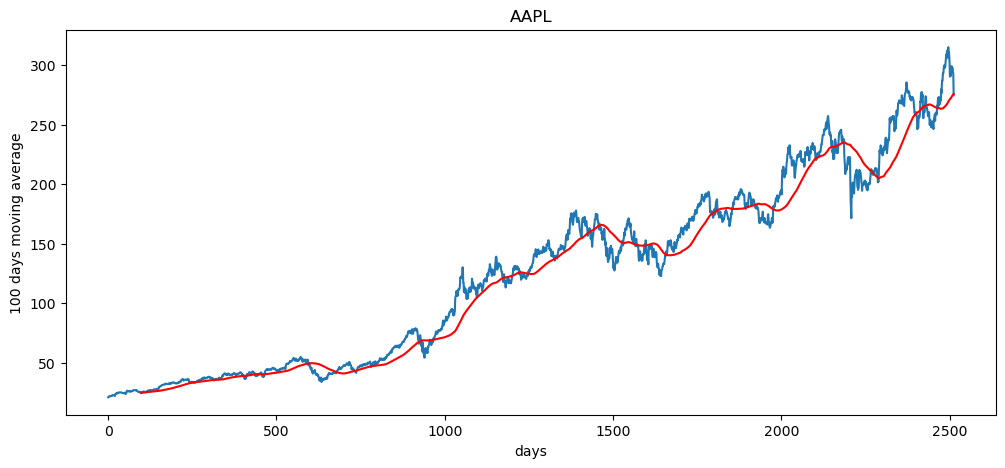

In [65]:
plt.figure(figsize=(12,5))
plt.plot(df.Close);
plt.plot(df['MA_100'],'r')
plt.title(ticker);
plt.xlabel('days')
plt.ylabel('100 days moving average');

In [66]:
df['MA_200'] = df.Close.rolling(200).mean()
df.head(204)

Price,Date,Close,High,Low,Open,Volume,MA_100,MA_200
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL,,
0,2016-06-27,20.952875,21.182802,20.829944,21.171419,181958400,NaN,NaN
1,2016-06-28,21.305725,21.321662,20.975634,21.148648,161779600,NaN,NaN
2,2016-06-29,21.490128,21.524275,21.314836,21.392238,146124000,NaN,NaN
3,2016-06-30,21.763309,21.802010,21.467366,21.499237,143345600,NaN,NaN
4,2016-07-01,21.829327,21.961364,21.701843,21.738266,104106000,NaN,NaN
...,...,...,...,...,...,...,...,...
199,2017-04-11,32.724384,33.121800,32.361626,33.027066,121517600,29.234916,26.948217
200,2017-04-12,32.763660,32.844528,32.581125,32.717450,81400000,29.309512,27.007271
201,2017-04-13,32.590366,32.897670,32.590366,32.789074,71291600,29.382467,27.063694


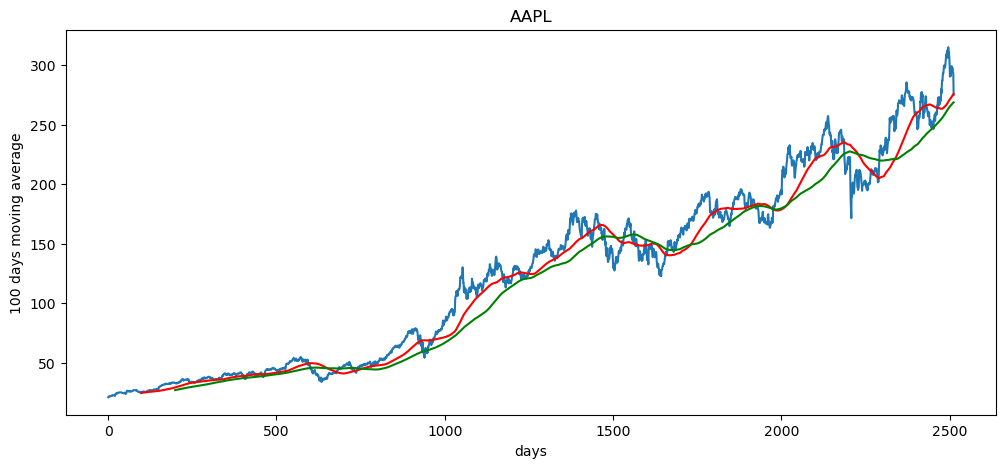

In [67]:
plt.figure(figsize=(12,5))
plt.plot(df.Close);
plt.plot(df['MA_100'],'r')
plt.plot(df.MA_200,'g')
plt.title(ticker);
plt.xlabel('days');
plt.ylabel('100 days moving average');

##Calculating % in each trading session



In [68]:
df['percentage changed'] = df.Close.pct_change()
df

Price,Date,Close,High,Low,Open,Volume,MA_100,MA_200,percentage changed
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL,,,
0,2016-06-27,20.952875,21.182802,20.829944,21.171419,181958400,NaN,NaN,NaN
1,2016-06-28,21.305725,21.321662,20.975634,21.148648,161779600,NaN,NaN,0.016840
2,2016-06-29,21.490128,21.524275,21.314836,21.392238,146124000,NaN,NaN,0.008655
3,2016-06-30,21.763309,21.802010,21.467366,21.499237,143345600,NaN,NaN,0.012712
4,2016-07-01,21.829327,21.961364,21.701843,21.738266,104106000,NaN,NaN,0.003033
...,...,...,...,...,...,...,...,...,...
2508,2026-06-18,298.010010,300.570007,295.619995,298.109985,85962200,274.548561,267.793002,0.006961
2509,2026-06-22,297.010010,302.420013,296.760010,297.309998,44879900,274.940750,268.089065,-0.003356
2510,2026-06-23,294.299988,301.640015,294.179993,297.540009,52010900,275.324106,268.365048,-0.009124


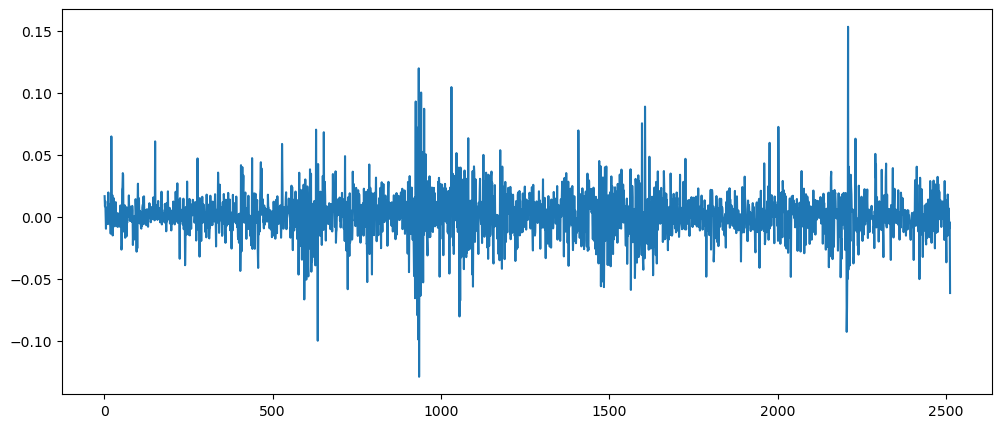

In [69]:
plt.figure(figsize=(12,5));
plt.plot(df['percentage changed']);

In [70]:
df

Price,Date,Close,High,Low,Open,Volume,MA_100,MA_200,percentage changed
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL,,,
0,2016-06-27,20.952875,21.182802,20.829944,21.171419,181958400,NaN,NaN,NaN
1,2016-06-28,21.305725,21.321662,20.975634,21.148648,161779600,NaN,NaN,0.016840
2,2016-06-29,21.490128,21.524275,21.314836,21.392238,146124000,NaN,NaN,0.008655
3,2016-06-30,21.763309,21.802010,21.467366,21.499237,143345600,NaN,NaN,0.012712
4,2016-07-01,21.829327,21.961364,21.701843,21.738266,104106000,NaN,NaN,0.003033
...,...,...,...,...,...,...,...,...,...
2508,2026-06-18,298.010010,300.570007,295.619995,298.109985,85962200,274.548561,267.793002,0.006961
2509,2026-06-22,297.010010,302.420013,296.760010,297.309998,44879900,274.940750,268.089065,-0.003356
2510,2026-06-23,294.299988,301.640015,294.179993,297.540009,52010900,275.324106,268.365048,-0.009124


##Data split for training and testing

In [71]:
data_training = pd.DataFrame(df.Close[0:int(len(df)*0.7)])
data_testing = pd.DataFrame(df.Close[int(len(df)*0.7): int(len(df))])
data_training
data_testing

Ticker,AAPL
1759,184.099075
1760,182.708557
1761,185.459976
1762,186.633575
1763,186.968857
...,...
2508,298.010010
2509,297.010010
2510,294.299988
2511,293.079987


In [72]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))


In [73]:
data_training_array = scaler.fit_transform(data_training)
data_training_array

array([[0.        ],
       [0.00215861],
       [0.00328672],
       ...,
       [0.98799427],
       [0.98165959],
       [1.        ]], shape=(1759, 1))

In [74]:
type(data_training_array)
data_training_array.shape

(1759, 1)

## Sequence Creation 

In [75]:
x_train = []
y_train = []
for i in range(100,data_training_array.shape[0]):
    x_train.append(data_training_array[i-100:i])
    y_train.append(data_training_array[i,0])

x_train,y_train = np.array(x_train),np.array(y_train) 

In [76]:
x_train.ndim

3

In [77]:
y_train.ndim

1

In [78]:
x_train.shape

(1659, 100, 1)

In [79]:
y_train.shape

(1659,)

In [80]:
import tensorflow as tf

In [81]:
#ML MODEL
from keras.models import Sequential
from keras.layers import Dense,LSTM,Input

In [82]:
model = Sequential()

model.add(Input(shape=(100,1)))
model.add(LSTM(units=128,activation='tanh',return_sequences=True))
model.add(LSTM(units=64))
model.add(Dense(25))
model.add(Dense(1))



## Model Training

In [83]:
model.compile(optimizer='adam',loss='mean_squared_error')
model.fit(x_train,y_train,epochs=50)

Epoch 1/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 22s 212ms/step - loss: 0.0126
Epoch 2/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 30s 399ms/step - loss: 6.7049e-04
Epoch 3/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 17s 317ms/step - loss: 7.2033e-04
Epoch 4/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 22s 336ms/step - loss: 6.3015e-04
Epoch 5/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 20s 310ms/step - loss: 6.1302e-04
Epoch 6/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 21s 316ms/step - loss: 5.8081e-04
Epoch 7/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 23s 364ms/step - loss: 5.8350e-04
Epoch 8/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 16s 271ms/step - loss: 5.7352e-04
Epoch 9/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 21s 271ms/step - loss: 5.0522e-04
Epoch 10/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 20s 261ms/step - loss: 4.5156e-04
Epoch 11/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 21s 270ms/step - loss: 4.7032e-04
Epoch 12/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 20s 258ms/step - loss: 4.3643e-04
Epoch 13/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 22s 289ms/step - loss: 4.3197e-04
Epoch 14/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 20s 270ms/step - loss: 4.

In [84]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 100, 128)            │          66,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 25)                  │           1,625 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              26 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 352,859 (1.35 MB)

 Trainable params: 117,619 (459.45 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 235,240 (918.91 KB)

In [85]:
model.save('Stock_Prediction_model.keras')

## 8.Preparing TestData

In [86]:
past_100_days = data_training.tail(100)

In [87]:
final_df = pd.concat([past_100_days,data_testing],ignore_index=True)

In [88]:
final_df

Ticker,AAPL
0,140.613480
1,141.881927
2,143.002914
3,148.302994
4,151.921585
...,...
849,298.010010
850,297.010010
851,294.299988
852,293.079987


In [89]:
input_data = scaler.fit_transform(final_df)
input_data.shape

(854, 1)

In [90]:
x_test = []
y_test = []

for i in range(100,input_data.shape[0]):
    x_test.append(input_data[i-100:i])
    y_test.append(input_data[i,0])


In [91]:
x_test,y_test = np.array(x_test),np.array(y_test)

In [92]:
x_test[0].shape

(100, 1)

## 9.Making Predictions

In [93]:
y_predicted = model.predict(x_test)

24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 145ms/step


In [95]:
y_predicted = scaler.inverse_transform(y_predicted.reshape(-1,1)).flatten()
y_test = scaler.inverse_transform(y_test.reshape(-1,1)).flatten()

In [96]:
y_predicted

array([182.72203, 183.32413, 183.21642, 183.94728, 185.06279, 186.02031,
       188.19637, 189.34416, 189.38542, 189.27786, 188.72612, 187.50517,
       186.37546, 186.288  , 186.7976 , 187.36966, 188.98389, 190.19678,
       191.37944, 191.3516 , 190.56406, 190.14937, 190.28532, 190.84653,
       190.84682, 191.69794, 192.67972, 193.01901, 191.92273, 190.35104,
       185.91698, 181.38655, 178.73058, 176.94637, 175.97353, 175.6063 ,
       176.10306, 176.0418 , 175.55664, 174.26073, 173.29669, 173.14389,
       173.71419, 175.58769, 175.67107, 175.95322, 176.69022, 178.62576,
       181.47972, 183.7029 , 185.5347 , 186.65923, 184.70526, 180.81769,
       178.01535, 176.82109, 175.4965 , 173.96167, 173.38603, 173.05272,
       173.86412, 175.11823, 174.92807, 173.8773 , 173.17345, 173.1839 ,
       172.07883, 170.54536, 169.45064, 168.98294, 169.63846, 170.02145,
       170.60855, 171.46255, 172.94707, 174.62752, 175.61206, 176.52522,
       177.39545, 177.32019, 176.95764, 176.10468, 

In [97]:
y_test

array([184.09907532, 182.70855713, 185.4599762 , 186.63357544,
       186.96885681, 191.28831482, 189.79917908, 188.68478394,
       189.15815735, 188.04377747, 186.00241089, 185.47973633,
       187.14637756, 187.90570068, 188.0536499 , 191.3079834 ,
       191.05162048, 192.40266418, 190.4598999 , 189.28634644,
       190.08514404, 190.94314575, 191.81095886, 190.54866028,
       193.12260437, 193.73400879, 192.90562439, 189.91751099,
       188.52697754, 179.47392273, 176.37733459, 177.31420898,
       175.72644043, 175.50952148, 175.56874084, 177.21789551,
       175.23298645, 174.36399841, 171.82609558, 172.30999756,
       173.64311218, 175.01576233, 178.85714722, 174.1763916 ,
       176.37850952, 177.93875122, 181.81965637, 185.30555725,
       185.52282715, 187.09294128, 187.32995605, 180.62477112,
       175.34162903, 175.95387268, 177.11912537, 174.09738159,
       172.03346252, 173.54438782, 172.82345581, 175.746521  ,
       176.83274841, 173.29751587, 171.75694275, 172.60

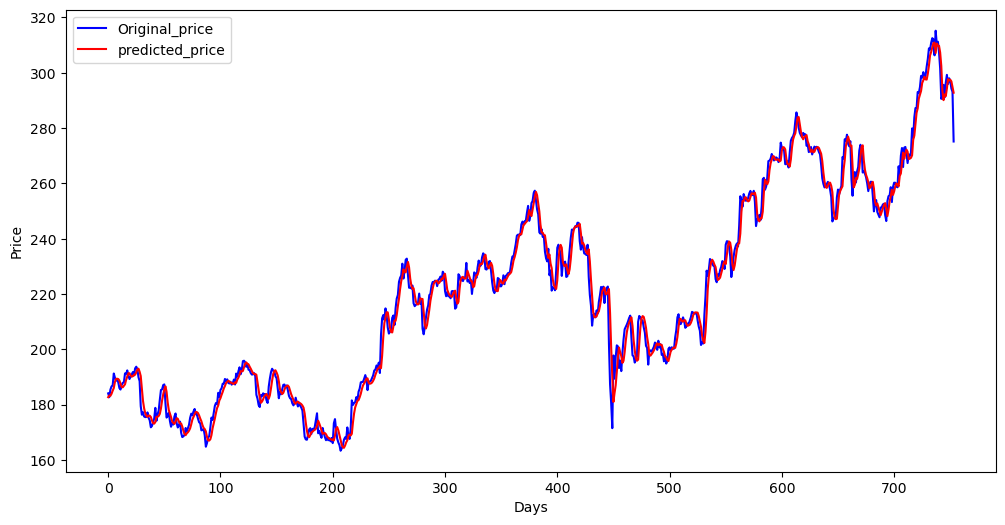

In [118]:
plt.figure(figsize=(12,6))
plt.plot(y_test,'b',label='Original_price')
plt.plot(y_predicted,'r',label='predicted_price')
plt.xlabel('Days')
plt.ylabel('Price')
plt.legend()

(160.0, 320.0)

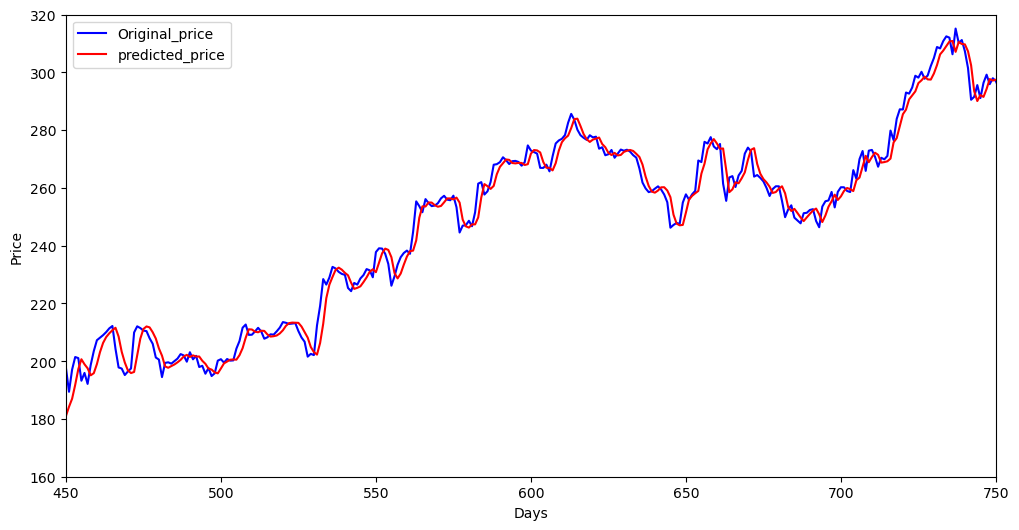

In [122]:
plt.figure(figsize=(12,6))
plt.plot(y_test,'b',label='Original_price')
plt.plot(y_predicted,'r',label='predicted_price')
plt.xlabel('Days')
plt.ylabel('Price')
plt.legend()
plt.xlim(450,750)
plt.ylim(160,320)

## Model Evaluation 

In [129]:
# Mean squared Error (MSE)
from sklearn.metrics import mean_squared_error,r2_score

In [133]:
mse = mean_squared_error(y_test,y_predicted)
print(f'Mean Squared Error (MSE) {mse}')

Mean Squared Error (MSE) 18.290019650717227


In [134]:
# Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)
print(f'Root mean squared Error (RMSE) : {rmse}')

Root mean squared Error (RMSE) : 4.276683253494141


In [135]:
r2 = r2_score(y_test,y_predicted)
print(f'R-Squared: {r2}')

R-Squared: 0.9862555729467902
